In [1]:
import os
os.chdir('../../../../..')

In [3]:
from src.datasets import MaterialsProject

In [10]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.helper_functions import create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [5]:
mp = MaterialsProject(limit=5000, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"], add_coulomb=True, add_soap=True, add_mace=True)
df = mp.load()

2026-04-21 10:03:49.513 | INFO     | src.datasets:load:1322 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-04-21 10:03:50.447 | INFO     | src.datasets:_add_descriptors:1671 - Ignoring output_tag=sample_n6000_seed40_stratified since descriptors are attached directly to dataframe.
2026-04-21 10:03:50.448 | INFO     | src.datasets:_add_descriptors:1675 - Extracting unique elements from formulas...
2026-04-21 10:04:05.444 | INFO     | src.datasets:_add_descriptors:1684 - Found 85 unique elements.
2026-04-21 10:04:05.455 | INFO     | src.datasets:_add_descriptors:1705 - Calculating max atoms for Coulomb Matrix padding...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /Users/karlfindhansen/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


2026-04-21 10:04:08.079 | INFO     | src.datasets:_add_descriptors:1752 - Computing Coulomb Matrix chunk 0 (0 to 1000)...
2026-04-21 10:04:08.676 | INFO     | src.datasets:_add_descriptors:1758 - Computing MACE chunk 0 (0 to 1000)...
2026-04-21 10:08:53.344 | INFO     | src.datasets:_add_descriptors:1729 - Computing SOAP chunk 1 (1000 to 2000)...
2026-04-21 10:08:56.308 | INFO     | src.datasets:_add_descriptors:1752 - Computing Coulomb Matrix chunk 1 (1000 to 2000)...
2026-04-21 10:08:57.458 | INFO     | src.datasets:_add_descriptors:1758 - Computing MACE chunk 1 (1000 to 2000)...
2026-04-21 10:13:38.834 | INFO     | src.datasets:_add_descriptors:1729 - Computing SOAP chunk 2 (2000 to 3000)...
2026-04-21 10:13:45.198 | INFO     | src.datasets:_add_descriptors:1752 - Computing Coulomb Matrix chunk 2 (2000 to 3000)...
2026-04-21 10:13:46.601 | INFO     | src.datasets:_add_descriptors:1758 - Computing MACE chunk 2 (2000 to 3000)...
2026-04-21 10:18:16.335 | INFO     | src.datasets:_add_d

In [7]:
# dist_matrix = mp.get_distance_matrix(
#     descriptor="acsf",
#     dist_type="euclidean",
#     force_calculate=True
# )

dist_matrix_soap = mp.get_distance_matrix(
    descriptor="soap",
    dist_type="euclidean",
    force_calculate=True,
    pca_variance=99.5,
)

dist_matrix_coulomb = mp.get_distance_matrix(
    descriptor="coulomb",
    dist_type="euclidean",
    force_calculate=True,
    pca_variance=95,
)


dist_matrix_mace = mp.get_distance_matrix(
    descriptor="mace",
    dist_type="euclidean",
    force_calculate=True,
    pca_variance=60,
)

2026-04-21 10:51:49.908 | INFO     | src.datasets:get_distance_matrix:1933 - Applying PCA to retain 99.50% of variance.
2026-04-21 10:51:50.119 | INFO     | src.datasets:get_distance_matrix:1942 - PCA reduced 'soap' dimensions from 252 to 4
2026-04-21 10:51:50.168 | INFO     | src.datasets:get_distance_matrix:1953 - Calculating distance matrix for soap using euclidean distance.
2026-04-21 10:51:50.562 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/Materials Project/dist_soap_euclidean_pca0.995.npy
2026-04-21 10:51:50.589 | INFO     | src.datasets:get_distance_matrix:1933 - Applying PCA to retain 95.00% of variance.
2026-04-21 10:53:38.420 | INFO     | src.datasets:get_distance_matrix:1942 - PCA reduced 'coulomb_matrix' dimensions from 10000 to 10
2026-04-21 10:53:38.451 | INFO     | src.datasets:get_distance_matrix:1953 - Calculating distance matrix for coulomb_matrix using euclidean distance.
2026-04-21 10:53:38.752 | SUCCESS  | src.distance:_compute_an

In [8]:
import numpy as np
import pandas as pd
from itertools import combinations
from tqdm import tqdm
from skbio.stats.distance import mantel

matrices = {
    "SOAP": dist_matrix_soap,
    "Coulomb": dist_matrix_coulomb,
    "Mace": dist_matrix_mace,
}

names = list(matrices.keys())
n = len(names)

# Initialize results matrix with 1.0 on the diagonal 
# (a metric perfectly correlates with itself)
results = np.zeros((n, n))
np.fill_diagonal(results, 1.0)

# Generate all unique pairs of indices (e.g., (0,1), (0,2)...)
# This prevents calculating A vs B and then redundantly calculating B vs A
pairs = list(combinations(range(n), 2))

# Define the worker function for the parallel pool
def compute_pair(i, j):
    """
    Runs the scikit-bio mantel test on a pair of matrices.
    """
    # 1. Cast the matrices to 64-bit floats (C 'double'). 
    # This simultaneously creates a writable copy, bypassing joblib's lock.
    mat_i = matrices[names[i]].astype(np.float64)
    mat_j = matrices[names[j]].astype(np.float64)
    
    # 2. Ensure the matrices are strictly "hollow" (diagonal == 0.0)
    np.fill_diagonal(mat_i, 0.0)
    np.fill_diagonal(mat_j, 0.0)

    # 3. Run the optimized mantel test
    r, p, _ = mantel(
        mat_i, 
        mat_j, 
        method='pearson', 
        permutations=999 
    )
    return i, j, r

print(f"Executing {len(pairs)} pairwise Mantel comparisons...")


# Loop through the pairs one by one using tqdm for a progress bar
for i, j in tqdm(pairs, desc="Computing pairs"):
    
    # Run the compute function
    _, _, r = compute_pair(i, j)
    
    # Immediately assign the result to the matrix (mirroring across the diagonal)
    results[i, j] = results[j, i] = r

# Convert to DataFrame for visualization
mantel_df = pd.DataFrame(results, index=names, columns=names)

print("\nFinal Mantel Correlation Matrix:")
print(mantel_df)

Executing 3 pairwise Mantel comparisons...


Computing pairs: 100%|██████████| 3/3 [01:59<00:00, 39.77s/it]


Final Mantel Correlation Matrix:
             SOAP   Coulomb      Mace
SOAP     1.000000  0.391434  0.306794
Coulomb  0.391434  1.000000  0.110261
Mace     0.306794  0.110261  1.000000


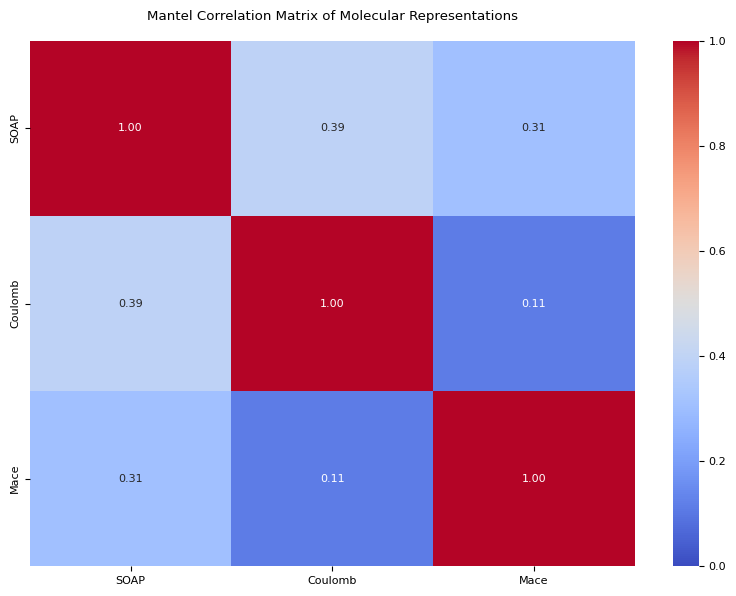

In [11]:
df = pd.DataFrame(mantel_df, index=names)
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, cmap="coolwarm", fmt=".2f", vmin=0, vmax=1)
plt.title("Mantel Correlation Matrix of Molecular Representations", pad=15)
plt.tight_layout()
#plt.savefig("mantel_heatmap.png", dpi=300)
plt.show()